
Label Distribution:
 label
Flop    150
Hit     100
Name: count, dtype: int64


/var/folders/r3/stfjytn503v31lz63tk6sw_00000gn/T/ipykernel_7105/2975380791.py:231: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


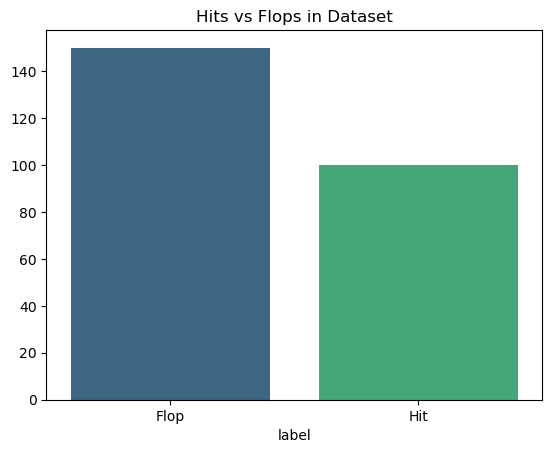

Epoch 1 | Loss: 0.6759 | Acc: 0.5886
Epoch 2 | Loss: 0.6454 | Acc: 0.6057
Epoch 3 | Loss: 0.6218 | Acc: 0.6343
Epoch 4 | Loss: 0.5810 | Acc: 0.6914
Epoch 5 | Loss: 0.5281 | Acc: 0.7257

Test Accuracy: 0.760
              precision    recall  f1-score   support

        Flop       0.72      0.98      0.83        45
         Hit       0.93      0.43      0.59        30

    accuracy                           0.76        75
   macro avg       0.82      0.71      0.71        75
weighted avg       0.80      0.76      0.73        75



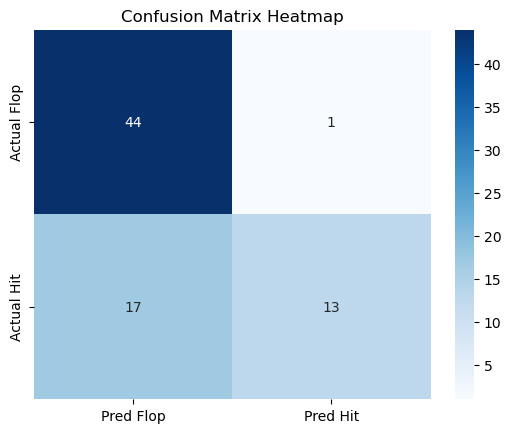

Files saved: model_weights.pt, scaler.pkl


In [ ]:
import os
import re
import numpy as np
import pandas as pd
from typing import Optional
import json 
import pickle 

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
import seaborn as sns

# ══════════════════════════════════════════════════════════════════════════════
# UTILITY FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def clean_currency(value) -> float:
    """Helper to convert scraped strings like '$11,400,000' to a float."""
    if pd.isna(value) or value == "N/A":
        return np.nan
    clean_str = re.sub(r'[^\d.]', '', str(value))
    try:
        return float(clean_str)
    except ValueError:
        return np.nan

def parse_movie_name(filename: str) -> str:
    """Parses movie key from filename (e.g., 'reviews_imdb_parasite.csv' -> 'parasite')"""
    name = os.path.splitext(filename)[0].lower()
    known_platforms = {"imdb", "rt", "letter", "letterboxd", "metacritic", "rottentomatoes"}
    for platform in known_platforms:
        name = re.sub(rf"_?{platform}_?", "_", name)
    name = re.sub(r"_?reviews_?$", "", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name

def parse_user_rating(val) -> float:
    """Normalizes various rating formats to a 0-10 float scale."""
    if pd.isna(val): return np.nan
    s = str(val).strip()
    pct = re.match(r"^([\d.]+)%$", s)
    if pct: return float(pct.group(1)) / 10.0
    frac = re.match(r"^([\d.]+)\s*/\s*([\d.]+)$", s)
    if frac:
        num, denom = float(frac.group(1)), float(frac.group(2))
        return (num / denom) * 10.0 if denom != 0 else np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING & LABELING
# ══════════════════════════════════════════════════════════════════════════════

def load_all_csvs(folder_path: str) -> pd.DataFrame:
    metadata_path = os.path.join(folder_path, "movie_metadata.csv")
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"Missing metadata file at: {metadata_path}")
    
    meta_df = pd.read_csv(metadata_path)
    # Create lookup for financial and metadata info
    financial_lookup = meta_df.set_index('movie_key')[['budget', 'gross_us', 'imdb_rating', 'year']].to_dict('index')

    all_dfs = []
    csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv") and f != "movie_metadata.csv"]

    for fname in csv_files:
        fpath = os.path.join(folder_path, fname)
        try:
            df = pd.read_csv(fpath)
            movie_key = parse_movie_name(fname)
            movie_data = financial_lookup.get(movie_key, {})

            # Map metadata to every row in the review dataframe
            df["budget"] = clean_currency(movie_data.get("budget"))
            df["gross"]  = clean_currency(movie_data.get("gross_us"))
            df["imdb_rating"] = pd.to_numeric(movie_data.get("imdb_rating"), errors='coerce')
            df["year"] = pd.to_numeric(movie_data.get("year"), errors='coerce')
            df["movie_title"] = movie_key

            if "user_rating" in df.columns:
                df["user_rating"] = df["user_rating"].apply(parse_user_rating)
            
            all_dfs.append(df)
        except Exception as e:
            print(f"  [skip] Error loading {fname}: {e}")

    if not all_dfs: raise ValueError("No valid movie review CSVs found.")
    return pd.concat(all_dfs, ignore_index=True)

def assign_label(row: pd.Series) -> float:
    budget, gross = row.get("budget"), row.get("gross")
    if pd.notna(budget) and budget > 0 and pd.notna(gross):
        return 1 if (gross / budget) >= 3.0 else 0 # Hit if 3x Budget
    return np.nan

# ══════════════════════════════════════════════════════════════════════════════
# PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

NUMERIC_FEATURES = ["avg_user_rating", "imdb_rating", "year"]

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # 1. Assign labels to the raw rows
    df["label"] = df.apply(assign_label, axis=1)
    
    # 2. Drop rows with missing financials
    df = df.dropna(subset=["label", "review_text"])
    
    # 3. Rename user_rating to avg_user_rating (so features match)
    df = df.rename(columns={"user_rating": "avg_user_rating"})
    
    # We DO NOT groupby("movie_title") here. 
    # Every review becomes its own training sample.
    
    df["label"] = df["label"].astype(int)
    return df

def build_numeric_matrix(movie_df: pd.DataFrame, scaler: Optional[StandardScaler] = None):
    X_num = movie_df[NUMERIC_FEATURES].fillna(0).values.astype(np.float32)
    if scaler is None:
        scaler = StandardScaler()
        X_num = scaler.fit_transform(X_num)
    else:
        X_num = scaler.transform(X_num)
    return X_num, scaler, NUMERIC_FEATURES

# ══════════════════════════════════════════════════════════════════════════════
# BERT DATASET & MODEL
# ══════════════════════════════════════════════════════════════════════════════

class MovieDataset(Dataset):
    def __init__(self, texts, numeric_features, labels, tokenizer, max_len=256):
        self.texts = texts
        self.numeric = torch.tensor(numeric_features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], max_length=self.max_len, 
                       truncation=True, padding="max_length", return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "numeric": self.numeric[idx],
            "label": self.labels[idx]
        }

class MovieClassifier(nn.Module):
    def __init__(self, num_dim: int, dropout: float = 0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        for name, param in self.bert.named_parameters():
            if not any(f"encoder.layer.{i}" in name for i in [10, 11]):
                param.requires_grad = False

        self.numeric_branch = nn.Sequential(
            nn.Linear(num_dim, 64), nn.ReLU(), nn.Dropout(dropout)
        )
        self.fusion = nn.Sequential(
            nn.Linear(768 + 64, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, input_ids, attention_mask, numeric):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_f = bert_out.last_hidden_state[:, 0, :]
        num_f = self.numeric_branch(numeric)
        return self.fusion(torch.cat([text_f, num_f], dim=1)).squeeze(1)

# ══════════════════════════════════════════════════════════════════════════════
# MAIN EXECUTION
# ══════════════════════════════════════════════════════════════════════════════

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    t_loss, correct, total = 0, 0, 0
    for b in loader:
        input_ids, mask, num, labels = b["input_ids"].to(device), b["attention_mask"].to(device), b["numeric"].to(device), b["label"].to(device)
        optimizer.zero_grad()
        logits = model(input_ids, mask, num)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        preds = (torch.sigmoid(logits) >= 0.5).float()
        t_loss += loss.item() * labels.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return t_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    t_loss, correct, total = 0, 0, 0
    all_p, all_l = [], []
    for b in loader:
        input_ids, mask, num, labels = b["input_ids"].to(device), b["attention_mask"].to(device), b["numeric"].to(device), b["label"].to(device)
        logits = model(input_ids, mask, num)
        loss = criterion(logits, labels)
        preds = (torch.sigmoid(logits) >= 0.5).float()
        t_loss += loss.item() * labels.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_p.extend(preds.cpu().int().tolist()); all_l.extend(labels.cpu().int().tolist())
    return t_loss / total, correct / total, all_p, all_l

def main(folder_path: str, epochs: int=5, batch_size: int=16, lr: float=2e-5, seed: int=42):
    torch.manual_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Load Data
    raw_df = load_all_csvs(folder_path)
    movie_df = preprocess(raw_df)

    # VISUALIZATION: Label Distribution
    label_counts = movie_df["label"].value_counts().rename({0: "Flop", 1: "Hit"})
    print("\nLabel Distribution:\n", label_counts)
    sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
    plt.title("Hits vs Flops in Dataset"); plt.show()

    # 2. FIXED SPLIT LOGIC (Avoids ValueError)
    if label_counts.min() < 2:
        print("[info] Dataset too small to stratify. Splitting randomly.")
        train_df, test_df = train_test_split(movie_df, test_size=0.3, random_state=seed)
    else:
        train_df, test_df = train_test_split(movie_df, test_size=0.3, random_state=seed, stratify=movie_df["label"])
    
    X_train, scaler, num_cols = build_numeric_matrix(train_df)
    X_test, _, _ = build_numeric_matrix(test_df, scaler)

    # 3. DataLoaders
    tok = BertTokenizer.from_pretrained("bert-base-uncased")
    train_ds = MovieDataset(train_df["review_text"].tolist(), X_train, train_df["label"].tolist(), tok)
    test_ds = MovieDataset(test_df["review_text"].tolist(), X_test, test_df["label"].tolist(), tok)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    # 4. Train
    model = MovieClassifier(num_dim=len(num_cols)).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    for epoch in range(1, epochs + 1):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion, device)
        print(f"Epoch {epoch} | Loss: {tl:.4f} | Acc: {ta:.4f}")

    # 5. Final Eval & Heatmap
    _, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)
    print(f"\nTest Accuracy: {test_acc:.3f}")
    print(classification_report(labels, preds, target_names=["Flop", "Hit"]))

    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Pred Flop", "Pred Hit"], yticklabels=["Actual Flop", "Actual Hit"])
    plt.title("Confusion Matrix Heatmap"); plt.show()

    # 6. Save
    torch.save(model.state_dict(), "model_weights.pt")
    with open("scaler.pkl", "wb") as f: pickle.dump({"scaler": scaler, "num_cols": num_cols}, f)
    print("Files saved: model_weights.pt, scaler.pkl")

if __name__ == "__main__":
    main('/Users/Diane/Desktop/PSYCH 186B/project/reviews/')